# SARIMAX

Прогнозирование сезонных временных рядов крайне важно, поскольку многие реальные бизнес-процессы, такие как продажи, спрос и погодные условия, следуют предсказуемым циклам. Прогнозирование этих сезонных паттернов позволяет компаниям и организациям оптимизировать ресурсы, улучшить планирование, снизить затраты и лучше удовлетворять потребности клиентов.

## Подготовка

In [ ]:
# Обработка данных
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

# Модели ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Модель Prophet
import prophet as fp
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import add_changepoints_to_plot

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL as STL_decomp, MSTL as MSTL_decomp

# Настройка
import itertools
from tqdm import tqdm


import warnings
warnings.filterwarnings("ignore")

In [ ]:
# !pip freeze

[Nixtla](https://nixtlaverse.nixtla.io/statsforecast/index.html) — компания, специализирующаяся на инструментах с открытым исходным кодом для прогнозирования временных рядов. Она стремится упростить процесс генерации точных прогнозов, предоставляя современные библиотеки и решения. Инструменты Nixtla особенно ориентированы на компании и специалистов по данным, работающих с задачами прогнозирования крупного масштаба. Их предложения легковесны, быстры и оптимизированы для современных задач прогнозирования.

*StatsForecast* — одна из ключевых библиотек Nixtla, разработанная для эффективного и масштабируемого прогнозирования временных рядов с использованием статистических (или эконометрических) моделей. Эта библиотека обычно ссылается на [Hyndman](https://otexts.com/fpp3/).

*UtilsForecast* — библиотека, созданная Nixtla в дополнение StatsForecast и др. Она фокусируется на расчете метрик, пайплайнах оценки и предобработке прогнозов.

In [ ]:
!pip install statsforecast


In [ ]:
# авто ARIMA и другие эконометрические модели
from statsforecast import StatsForecast
from statsforecast.models import (
    MSTL,
    AutoARIMA,
    SeasonalNaive,
    HistoricAverage,
    AutoETS,
    AutoTBATS,
    AutoCES,
    AutoTheta,
    HoltWinters
  )


# Оценка качества
from utilsforecast.losses import rmse, mape
from utilsforecast.evaluation import evaluate

In [ ]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

## Данные

Далее мы будем прогнозировать продажи (unit sales) тысяч товаров, продающихся в магазинах сети «Favorita» в Эквадоре. Обучающий датасет содержит даты, информацию о магазине и товаре, признаки промо-акций, а также объёмы продаж. Дополнительные файлы дают вспомогательные признаки, полезные при построении моделей.

Данные взяты с [Kaggle](https://www.kaggle.com/competitions/favorita-grocery-sales-forecasting/data?select=train.csv.7z). Скачать набор можно [здесь](https://drive.google.com/file/d/1xF5HXH0_fJlSr82A0nRehu6NVeq6mvhR/view?usp=sharing).

In [ ]:
# # Подготовка данных с Kaggle — этот код запускать не нужно

# df_train = pd.read_csv('train.csv', parse_dates=['date'])
# df_stores = pd.read_csv('stores.csv')
# df_item = pd.read_csv('items.csv')

# df_train = pd.merge(df_train, df_item, on='item_nbr', how='left')
# df_train = pd.merge(df_train, df_stores, on='store_nbr', how='left')

# df_full = pd.pivot_table(df_train, values='unit_sales', index=['date','city', 'state','type','family'],
#                aggfunc='sum').reset_index()

# df_full.to_csv('train_data.csv')

In [ ]:
sales_raw = pd.read_csv('train_data.csv', parse_dates=['date'])
sales_raw

Мы рассмотрим общие продажи компании. Подготовим датасет.

Для этого урока мы возьмем полный датасет за период 2013-2017.

In [ ]:
sales = pd.pivot_table(sales_raw, index='date', values='sales', aggfunc='sum').reset_index()
sales.columns = ['ds', 'y']
sales = sales.set_index('ds')
sales

Теперь построим график данных.

In [ ]:
fig = px.line(sales, x=sales.index, y=sales['y'],
              title="Sales of Favorita")

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="sales")
fig.show()

Теперь разделим данные на обучающую и тестовую выборки. Возьмем 2017 год для теста и 2013-2016 — для обучения.

In [ ]:
train_size = len(sales.loc['2013-01-01':'2016-12-31'])
train, test = sales[:train_size], sales[train_size:]

train.reset_index(inplace=True)
test.reset_index(inplace=True)

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="sales")
fig.show()

## Декомпозиция


Вы можете помнить с прошлой лекции, что по логике наш временной ряд должен быть декомпозирован. Мы предполагаем несколько сезонностей: недельную, месячную и годовую. Для этого мы будем использовать MSTL декомпозицию.

In [ ]:
mstl = MSTL_decomp(train['y'],  periods=[7,31,365])
res = mstl.fit()

fig = res.plot()
fig.set_size_inches(10, 6)
plt.show()

res.resid.plot()

Чтобы оценить качестао декомпозиции, давайте посмотрим на остатки. Как всегда, мы будем тестировать их на автокорреляцию и стационарность.

In [ ]:
acorr_ljungbox(res.resid, return_df=True)

In [ ]:
# 2 графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(res.resid.dropna(), ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(res.resid.dropna(), ax=ax[1], lags=20)
ax[1].set_title('PACF')


plt.tight_layout()
plt.show()

In [ ]:
adf_test(res.resid)

🐀 **Что мы ожидаем от остатков?**

В идеале мы ожидаем, что наши остатки не будут автокоррелированы и будут стационарными. **Наши остатки стационарны, но автокоррелированы.**

К сожалению, для многих реальных сценариев мы можем получить автокоррелированные остатки. На прошлом уроке мы обсуждали несколько причин, почему это может происходить.

Я пробовал классическую, STL и MSTL декомпозиции с разными сезонными периодами, но это не помогло сделать остатки некоррелированными. Таким образом, другой способ исправить остатки — использовать другую декомпозицию.

## Мультипликативная декомпозиция

На самом деле существуют два типа декомпозиции: аддитивная и мультипликативная. Ранее мы обсуждали только аддитивную.

Математическое выражение для **аддитивного временного ряда** выглядит так:

$𝑦_t = T_t + S_t + R_t$

Математическое выражение для **мультипликативного временного ряда** выглядит так:

$𝑦_t = T_t * S_t * R_t$

Временной ряд можно считать аддитивным, если его паттерны роста или снижения остаются постоянными на протяжении всего ряда. Однако, если амплитуда сезонных колебаний заметно изменяется со временем (обычно увеличивается), используется мультипликативная модель.

![image.png](https://www.researchgate.net/publication/348592737/figure/fig2/AS:981645804961802@1611054006728/Examples-for-multiplicative-and-additive-relationship-between-time-series-components.png)

Давайте вспомним наш временной ряд.

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
test
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="sales")
fig.show()

🐀 **Какая декомпозиция подойдет нашему временному ряду: аддитивная или мультипликативная?**

Иногда бывает непросто определить тип декомпозиции "на глаз". Давайте попробуем в этом случае.

К сожалению, MSTL не поддерживает мультипликативную декомпозицию по умолчанию. Так что же мы можем сделать?

Давайте вспомним замечательное правило: $log(a) + log(b) = log(ab)$.

**Что мы должны сделать?**

1.   Применить логарифм к нашему временному ряду.
2.   Декомпозировать логарифмически преобразованный временной ряд с использованием аддитивной декомпозиции с MSTL.
3.   Преобразовать полученные компоненты обратно => у нас есть мультипликативная декомпозиция — успех!

Давайте попробуем.

In [ ]:
train['log_y'] = np.log(train['y'])

fig = px.line(train, x=train.ds, y=train.log_y,
              title="log(sales)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.show()

In [ ]:
mstl_multi = MSTL_decomp(train['log_y'], periods=(7,31,365))
res_multi = mstl_multi.fit()

fig = res_multi.plot()
fig.set_size_inches(10, 6)
plt.show()

res_multi.resid.plot()

**Но как мы обратим преобразование?**

Теперь давайте узнаем, как преобразовать наш временной ряд обратно. Напомним, что: $y = ln(x)$ <=> $x = e^y$ — это будет наше преобразование.

Давайте восстановим *log_y*. Аналогично вы можете обработать тренд, сезонности, остатки.


In [ ]:
train['y_restored'] = np.exp(train['log_y'])
train

Помните, что наша первоначальная цель с мультипликативной декомпозицией состояла в том, чтобы получить неавтокоррелированный и стационарный временной ряд.

Давайте проверим остатки на этот раз.

In [ ]:
acorr_ljungbox(res_multi.resid, return_df=True)

In [ ]:
adf_test(res_multi.resid)

Тем не менее, наши остатки автокоррелированы и стационарны.

Таким образом, единственное, что можно сделать здесь, — это смоделировать остатки с помощью ARIMA, а затем проверить остатки остатков на автокорреляцию и стационарность.

Сегодня мы не будем этого делать, но я рекомендую вам попробовать это в домашнем задании 2.

Давайте избавимся от ненужного логарифмического столбца.

In [ ]:
train.drop(['log_y', 'y_restored'], axis=1, inplace=True)

## Прогнозирование с SARIMA

Сезонность можно прогнозировать несколькими способами. На прошлом уроке мы обсуждали модель SARIMA.

**SARIMA** - Seasonal Autoregressive Integrated Moving Average (сезонная авторегрессионная интегрированная скользящая средняя). Это расширение модели ARIMA, но с дополнительными компонентами, которые помогают улавливать сезонные паттерны во временных рядах.

$$SARIMA(p,d,q)×(P,D,Q)_m​$$

Длина будущего периода, на который делаются прогнозы в задаче прогнозирования временных рядов, обычно называется **горизонтом**.

In [ ]:
forecast_horizon = len(sales) - train_size
forecast_horizon

Сегодня мы будем использовать реализацию SARIMA из *statsforecast* (от Nixtla). Чтобы использовать *statsforecast*, вы должны подготовить свои данные.

В вашем датасете должны присутствовать три столбца:
* **y** — целевой столбец, содержащий значения для прогнозирования.
* **ds** — столбец с датами.
* **unique_id** — столбец, представляющий уникальный идентификатор для каждого временного ряда. *statsforecast* позволяет одновременно работать с временными рядами с несколькими измерениями. Например, в нашем датасете мы могли бы прогнозировать продажи каждой отдельной группы продуктов => группа продуктов была бы нашим измерением.

In [ ]:
# Давайте создадим unique_id
train['unique_id'] = 'sales'
train

Теперь перейдем к построению модели SARIMA.

In [ ]:
# Инициализация модели
models = [AutoARIMA(seasonal=True, season_length=7, approximation=True)]
sf = StatsForecast(models=models, freq='D', n_jobs=-1, fallback_model=HistoricAverage())

# Обучение модели
sf = sf.fit(df=train)

In [ ]:
result=sf.fitted_[0,0].model_

result

In [ ]:
# Прогноз
forecast = sf.predict(h=forecast_horizon)
forecast.columns = ['unique_id', 'ds', 'y_hat']

forecast

Обратите внимание, что реализация SARIMA от Nixtla дает нам плохой прогноз на большое расстояние (мы уже видели это в statsmodels ARIMA на уроках 3-4).

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['y_hat'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

Вы также можете проанализировать остатки модели

In [ ]:
residual = pd.DataFrame(result.get("residuals"), columns=["residual Model"])
residual

In [ ]:
from scipy.stats import norm # для визуализации нормального распределения


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# plot[1,1]
residual.plot(ax=axs[0,0])
axs[0,0].set_title("Residuals")

# plot
sns.distplot(residual, ax=axs[0,1], fit=norm) # add fit=norm to visualize norm distribution
axs[0,1].set_title("Density plot - Residual")

# plot
stats.probplot(residual["residual Model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot Q-Q')

# plot
plot_acf(residual,  lags=35, ax=axs[1,1],color="fuchsia")
axs[1,1].set_title("Autocorrelation")

plt.show()

🐀 **Что вы можете сказать об остатках модели?**

Теперь давайте вычислим метрики качества RMSE и MAPE для оценки нашего прогноза.

Помните:

* **MAE**: Когда вам нужна легкая для понимания метрика, которая обрабатывает все ошибки одинаково, без штрафа за большие ошибки.
* **RMSE**: Когда вам нужна метрика, которая более сильно штрафует за большие ошибки и более чувствительна к выбросам.
* **MAPE**: Когда вам нужны процентные ошибки, но избегайте этого, если в ваших данных есть нулевые значения.
* **MDAPE**: Когда ваши данные содержат выбросы или смещены, и вы хотите более устойчивую метрику, чем MAPE.
* **MASE**: Когда вы хотите сравнить производительность вашей модели с наивным прогнозом, особенно в перекрестных исследованиях. Полезно для сравнения моделей на разных датасетах.
* **SMAPE**: Когда вы хотите симметричную процентную ошибку, которая более стабильна, чем MAPE, особенно когда данные могут содержать нули.

Мы будем в основном использовать RMSE и MAPE.

In [ ]:
metrics = [rmse, mape]

In [ ]:
evaluation_sarima = evaluate(
    test.merge(forecast),
    metrics=metrics,
    train_df=train
)
evaluation_sarima

🐀 **Что вы можете сказать о качестве прогноза?**

## Прогнозирование с SARIMAX


**SARIMAX** (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors — сезонная авторегрессионная интегрированная скользящая средняя с экзогенными регрессорами) — это расширение модели SARIMA, которое включает внешние регрессоры.

Давайте рассмотрим 2 регрессора, рекомендованные авторами Kaggle: цены на нефть (Эквадор — страна, зависимая от нефти) и праздники.

Цены на нефть — это непрерывный регрессор, а праздники — фиктивный регрессор.

Давайте начнем с цен на нефть — непрерывного регрессора.

In [ ]:
oil = pd.read_csv('oil.csv', parse_dates=['date'])
oil.columns = ['ds','oil']
oil = oil.set_index('ds')
oil = oil.loc[sales.index.min():sales.index.max()]
oil

In [ ]:
oil = oil.join(sales, how='right')['oil'].fillna(method='bfill')
oil = pd.DataFrame(oil)
oil

Теперь давайте обработаем праздники как фиктивные регрессоры.

In [ ]:
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])
holidays = holidays[(holidays['locale'] == 'National')&(holidays['locale_name'] == 'Ecuador')] # мы будем учитывать только национальные праздники Эквадора
holidays

In [ ]:
holidays['ds'] = holidays['date']
holidays = holidays[['ds', 'description']]
holidays = pd.DataFrame(holidays)
holidays.set_index('ds', inplace=True)
holidays = holidays.loc[sales.index.min():sales.index.max()]
holidays

In [ ]:
holidays_dummy = holidays.join(sales, how='right')
holidays_dummy['holiday'] = 1 - holidays_dummy.description.isna()
holidays_dummy = pd.DataFrame(holidays_dummy['holiday']).join(sales)
holidays_dummy

Давайте объединим наши регрессоры в один датафрейм.

In [ ]:
regressors = oil.join(holidays_dummy, how='outer')[['oil', 'holiday']]
regressors['unique_id'] = 'sales' # добавляем unique_id для Nixtla
regressors

Давайте построим график регрессоров.

In [ ]:
fig = px.line(title="Holidays dummy regressor")
fig.add_scatter(x=regressors[:train_size].index, y=regressors[:train_size]['holiday'], mode='lines', name='Holidays for train', line=dict(color='blue'))
fig.add_scatter(x=regressors[train_size:].index, y=regressors[train_size:]['holiday'], mode='lines', name='Holidays for forecast', line=dict(color='green'))

fig.update_layout(template='plotly_white', width=1000, height=400)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="closing price")
fig.show()

Давайте также посмотрим, как цены на нефть связаны с временным рядом. Похоже, что цены на нефть не очень коррелируют с продажами. Тем не менее, мы все еще будем учитывать этот регрессор и посмотрим, улучшит ли он качество.

In [ ]:
import plotly.graph_objects as go

# Создать пустой график
fig = go.Figure()

# Добавить график y слева
fig.add_trace(go.Scatter(
    x=sales.index,
    y=sales['y'],
    mode='lines',
    name='y',
    line=dict(color='blue'),
    yaxis='y1'  # Привязать к y1
))

# Добавить график x справа
fig.add_trace(go.Scatter(
    x=regressors.index,
    y=regressors['oil'],
    mode='lines',
    name='oil prices',
    line=dict(color='red'),
    yaxis='y2'  # Привязать к y1
))


fig.update_layout(
    title="Sales",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='y',
    ),
    yaxis2=dict(
        title='oil prices',
        overlaying='y',  # Наложить оси
        side='right'
    ),
    xaxis=dict(title='Date')
)

# Отображаем график
fig.show()

Регрессоры также должны быть разделены на обучающую и тестовую выборки.

In [ ]:
regressors_train, regressors_test = regressors.loc[:'2016-12-31'], regressors['2017-01-01':]
regressors_train = regressors_train.reset_index()
regressors_test = regressors_test.reset_index()
regressors_test

Давайте обучим модель.

In [ ]:
# Инициализация модели
models = [AutoARIMA(seasonal=True, season_length=7, approximation=True)]
sf_with_reg = StatsForecast(models=models, freq='D', n_jobs=-1)

# метод forecast объединяет fit и predict и работает быстрее благодаря оптимизации
forecast_with_reg = sf_with_reg.forecast(df=train.merge(regressors_train, how='left', on=['unique_id', 'ds']),
                                         X_df=regressors_test, h=forecast_horizon)


In [ ]:
forecast_with_reg.columns = ['unique_id', 'ds', 'y_hat']
forecast_with_reg

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['y_hat'], mode='lines', name='forecast', line=dict(color='red'))
fig.add_scatter(x=forecast_with_reg['ds'], y=forecast_with_reg['y_hat'], mode='lines', name='forecast_with_reg', line=dict(color='orange'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

И наконец, давайте оценим прогноз.

In [ ]:
evaluation_sarimax = evaluate(
    test.merge(forecast_with_reg),
    metrics=metrics,
    train_df=train
)
evaluation_sarimax

Сравним с исходной моделью:

In [ ]:
print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

Модель SARIMAX от Nixtla не очень подходит для долгосрочных прогнозов. Однако она может обеспечить хороший прогноз для меньших горизонтов и стабильный базовый уровень.

## Резюме по SARIMAX

- Пересмотрели наш датасет и задачу
- Обсудили мультипликативную декомпозицию и как ее можно достичь для MSTL с логарифмическим преобразованием (хотя MSTL работает только с аддитивной декомпозицией)
- Прогнозировали с моделями SARIMA и SARIMAX из statsforecast (Nixtla)
- Оценили прогнозы с помощью RMSE и MAPE

# Prophet - ML модель прогнозирования

Модель прогнозирования Prophet разработана для прогнозирования временных рядов и адаптирована для обработки общих бизнес-характеристик во временных рядах (множественная сезонность, изменения тренда, праздники).

Подробное описание методологии, реализованной в Prophet, можно найти в оригинальной статье [Taylor & Letham 2017](https://peerj.com/preprints/3190.pdf). Вкратце, методология основана на подгонке аддитивных регрессионных моделей со следующими четырьмя ключевыми компонентами:

**$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$**

* Тренд $g(t)$ — это кусочно-линейная или кусочно-логистическая кривая роста. Линейная кривая проста, в то время как логистическая функция вида $g(t) = \frac{C}{1+\exp(-k(t-b))}$ позволяет моделировать рост с насыщением, где скорость роста уменьшается по мере увеличения показателя. Библиотека также может выбрать оптимальные точки изменения для тренда из исторических данных.

* Сезонные компоненты $s(t)$ моделируют периодические изменения, связанные с недельной и годовой сезонностью. Эти компоненты моделируются с помощью рядов Фурье.

* Компонента $h(t)$ моделирует пользовательские праздники и выходные дни, то есть периоды аномального поведения метрики. "Праздники" в FBProphet также включают нерегулярные праздники, промо-дни, и даже период COVID-19 может быть захвачен в этом компоненте. Праздники представлены как фиктивные переменные.

* Ошибка $\textbf{$\varepsilon_t$}$ — нормально распределенные случайные процессы. Этот компонент учитывает информацию, которая не объясняется моделью.

## Базовая модель

Давайте начнем с базовой модели прогнозирования Prophet.

In [ ]:
# Для Prophet нам не понадобится unique_id - prophet работает только с одномерными временными рядами.
train_fp = train[['ds', 'y']]
test_fp = test[['ds', 'y']]

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m = fp.Prophet()

# 2. Обучить модель
m.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_prophet = m.predict(future)

Forecast — это таблица pd.DataFrame, которая содержит значения, рассчитанные на основе модели *m*.
Она включает тренд, сезонные компоненты модели, прогнозируемые значения, а также верхние и нижние границы доверительных интервалов


In [ ]:
# Вот как выглядят первые несколько прогнозируемых значений метрики и их (по умолчанию) 80% доверительные границы:
forecast_prophet.head()

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [ ]:
forecast_prophet['unique_id'] = 'sales'

evaluation_prophet = evaluate(
    test.merge(forecast_prophet[['unique_id','ds','yhat']]),
    metrics=metrics,
    train_df=train
)
evaluation_prophet

In [ ]:
print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

print('Base Prophet:')
display(evaluation_prophet)

## Гиперпараметры, которые следует учитывать

[Полный список гиперпараметров модели Prophet с описаниями.](https://facebook.github.io/prophet/docs/diagnostics.html)

Все параметры соответствуют каждому компоненту временного ряда:
- Тренд
    - **changepoint_prior_scale**
    - **changepoint_range**    
    - growth
    - changepoints
    - n_changepoints

- Сезонность
    - **seasonality_prior_scale**
    - **seasonality_mode**  
    - yearly_seasonality
    - weekly_seasonality

- Праздники
    - **holidays**
    - **holidays_prior_scale**
  
В документации Prophet рекомендуется изменять гиперпараметры, выделенные жирным шрифтом. Давайте рассмотрим их более подробно:

- **changepoint_prior_scale** — Параметр, который управляет чувствительностью автоматического определения точки изменения в тренде временного ряда y (значение по умолчанию равно 0,05). Более высокие значения позволяют увеличить количество точек изменения (что также увеличивает риск переобучения модели).

- **changepoint_range** — Доля исторических данных (начиная с самого первого наблюдения), которая будет использоваться для оценки точек изменения. Значение по умолчанию равно 0,8 (т.е. 80% наблюдений).

- **seasonality_prior_scale** — Параметр, который определяет силу сезонных составляющих модели (значение по умолчанию равно 10). Более высокие значения приводят к "гибкой" модели, в то время как более низкие значения приводят к модели с более слабыми сезонными эффектами. Этот параметр можно задать отдельно для каждого типа сезонности с помощью функции add_seasonality().

- **seasonality_mode** — Режим для моделирования сезонных составляющих. Он принимает два возможных значения: "additive" (по умолчанию) и "multiplicative".

- **holidays** — Таблица, содержащая два обязательных столбца: holiday (string переменная с названиями праздников) и ds (даты). При желании вы можете добавить еще два столбца: *lower_window* и *upper_window*, которые определяют временной интервал вокруг события. Например, при "lower_window = -2" в модель будет добавлено 2 дня, предшествующих событию.

- **holidays_prior_scale** — Параметр, определяющий силу влияния праздников и других важных событий (по умолчанию - 10).

### Гиперпараметры, связанные с сезонностью

**Parameters controlling the components of seasonality**

**seasonality_prior_scale** - параметр определяет гибкость сезонности (обычно в диапазоне [0,01, 10]).

**seasonality_mode** - параметр, отвечающий за величину сезонности (может быть ['additive', 'multiplicative'])

***yearly_seasonality*** - параметр соответствует годовой сезонности (может быть "auto", True, False или порядок Фурье для генерации)

***weekly_seasonality*** - параметр соответствует еженедельной сезонности (может быть 'auto', True, False, или порядок Фурье для генерации)

[Read more here](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#fourier-order-for-seasonalities)


Давайте посмотрим, как Prophet декомпозировал наш временной ряд.

Prophet использует регрессионный подход для декомпозиции временного ряда на его базовые компоненты, а именно:

* **Компонента тренда**: Общая долгосрочная прогрессия данных (которая может быть линейной или логистической). Prophet моделирует тренд с помощью кусочно-линейной или логистической функции, где точки разрыва (change points), где тренд изменяется, могут быть автоматически обнаружены. Тренд по существу является базовым паттерном роста или снижения во временном ряду.

* **Компонента сезонности**: Это захватывает периодические паттерны, такие как дневные, недельные или годовые циклы. Prophet позволяет вам указать сезонности (например, годовую и недельную) и моделирует их с помощью рядов Фурье для захвата циклического поведения. По умолчанию Prophet включает годовую и недельную сезонность, но вы можете добавить пользовательские сезонности (например, месячную или квартальную).

* **Эффекты праздников**: Prophet позволяет включать праздники или другие специальные события (такие как распродажи, общекорпоративные промо-акции или внешние шоки, такие как пандемия COVID-19) в качестве дополнительных регрессоров. Они моделируются как фиктивные переменные, и Prophet корректирует временной ряд на любые внезапные изменения в данных, вызванные этими событиями.

In [ ]:
# Вы можете отобразить компоненты прогноза
# По умолчанию вы увидите тренд, годовую сезонность и недельную сезонность временного ряда
# Если вы включили праздники, вы увидите их здесь

fig2 = m.plot_components(forecast_prophet)

#### Виды сезонности

Prophet позволяет вам работать как с аддитивными, так и с мультипликативными сезонностями. Это можно настроить с помощью параметра **seasonality_mode**.

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_2 = fp.Prophet(seasonality_mode = 'multiplicative') # обратите внимание на seasonality mode

# 2. Обучить модель
m_2.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_2.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_2 = m_2.predict(future)

Forecast — это pd.DataFrame, которая содержит значения, рассчитанные на основе модели *m*.
Она включает тренд, сезонные компоненты модели, прогнозируемые значения, а также верхние и нижние границы доверительных интервалов


In [ ]:
fig = px.line(title="Продажи")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='прогноз', line=dict(color='red'))
fig.add_scatter(x=forecast_2['ds'], y=forecast_2['yhat'], mode='lines', name='forecast with multi', line=dict(color='orange'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="продажи")
fig.show()

#### Порядки Фурье


Prophet моделирует сезонность, используя ряды Фурье для захвата периодических паттернов во временном ряду, таких как годовые, недельные или пользовательские сезонные эффекты. Этот метод довольно гибкий и позволяет Prophet эффективно моделировать сложные, нелинейные сезонные паттерны.

Одним из более тонких параметров является порядок Фурье. Порядок Фурье определяет, насколько быстро сезонность может изменяться (**по умолчанию для годовой сезонности — 10, для недельной — 3**). Увеличение порядка Фурье позволяет сезонности адаптироваться к быстро меняющимся циклам.

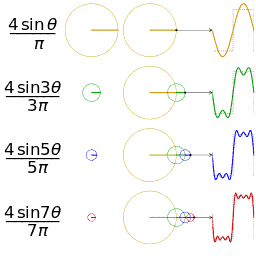

В модели Prophet вы можете добавить пользовательские сезонности. Каждая сезонность определяется количеством членов Фурье (гиперпараметры **weekly_seasonality**, **yearly_seasonality**, или **fourier_order** при добавлении пользовательской сезонности) и количеством наблюдений в одном цикле (параметр **period**, который равен 365.25 для годовой сезонности и 7 для недельной). Уменьшение **fourier_order** приводит к более гладкой сезонности, в то время как его увеличение дает больше гибкости сезонному компоненту. Изменения более заметны для годовой сезонности, потому что в одном цикле просто больше наблюдений, что позволяет использовать более сложные ряды Фурье.

In [ ]:
m_3 = fp.Prophet(
    seasonality_mode = 'additive',
    yearly_seasonality = False) # выключаем годовую сезонность

# Добавляем скорректированную годовую сезонность
m_3.add_seasonality(name = 'yearly',
                       period = 365.25,
                       fourier_order = 25, # порядок Фурье для годовой сезонности был увеличен
                       mode = 'multiplicative')
m_3.fit(train_fp)

future = m_3.make_future_dataframe(periods=forecast_horizon)

forecast_3 = m_3.predict(future)

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecas', line=dict(color='red'))
fig.add_scatter(x=forecast_2['ds'], y=forecast_2['yhat'], mode='lines', name='forecast with multi', line=dict(color='orange'))
fig.add_scatter(x=forecast_3['ds'], y=forecast_3['yhat'], mode='lines', name='forecast with adjusted yearly (increased fourier)', line=dict(color='brown'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="y")
fig.update_yaxes(title_text="продажи")
fig.show()

Теперь давайте уменьшим порядок Фурье для годовой сезонности.

In [ ]:
m_4 = fp.Prophet(
    seasonality_mode = 'additive',
    yearly_seasonality = False) # выключаем годовую сезонность

# Добавляем скорректированную недельную сезонность
m_4.add_seasonality(name = 'yearly',
                       period = 365.24,
                       fourier_order = 2, # порядок Фурье для годовой сезонности был уменьшен
                       mode = 'multiplicative')
m_4.fit(train_fp)

future = m_4.make_future_dataframe(periods=forecast_horizon)

forecast_4 = m_4.predict(future)

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecast', line=dict(color='red'))
fig.add_scatter(x=forecast_2['ds'], y=forecast_2['yhat'], mode='lines', name='forecast with multi', line=dict(color='orange'))
fig.add_scatter(x=forecast_3['ds'], y=forecast_3['yhat'], mode='lines', name='forecast with adjusted yearly (increased fourier)', line=dict(color='brown'))
fig.add_scatter(x=forecast_4['ds'], y=forecast_4['yhat'], mode='lines', name='forecast with adjusted yearly (decreased fourier)', line=dict(color='pink'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="продажи")
fig.show()

#### Масштаб априорной вероятности сезонности

Стандартный ряд Фурье представляет собой сумму синусов и косинусоид с определенными коэффициентами.

Предполагается, что предварительное распределение этих коэффициентов равно $N(0,σ^ 2)$. Значение **seasonality_prior_scale** определяет гибкость сезонности: **при более низких значениях сезонность проявляется слабо, а при более высоких значениях сезонность становится более заметной**. По умолчанию установлено значение 10.

Ожидается, что он будет установлен в пределах [0.01, 10] (см. [рекомендации](https://facebook.github.io/prophet/docs/diagnostics.html) от авторов), однако вы можете настроить его. Исходя из моего личного опыта, настройка в диапазоне [0.1, 10] обычно не оказывает никакого влияния. Однако уменьшение может привести к более интересным результатам. Я рекомендую настроить его в пределах [0.001, 0.1].

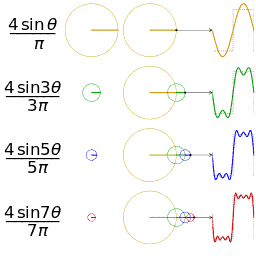

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_5 = fp.Prophet(seasonality_prior_scale = 25) # увеличенная seasonality_prior_scale

# 2. Обучить модель
m_5.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_5.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_5 = m_5.predict(future)

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecast', line=dict(color='red'))
fig.add_scatter(x=forecast_5['ds'], y=forecast_5['yhat'], mode='lines', name='forecast with seasonality_prior_scale = 25', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_6 = fp.Prophet(seasonality_prior_scale = 0.01) # уменьшенная seasonality_prior_scale

# 2. Обучить модель
m_6.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_6.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_6 = m_6.predict(future)

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecast', line=dict(color='red'))
fig.add_scatter(x=forecast_6['ds'], y=forecast_6['yhat'], mode='lines', name='forecast with seasonality_prior_scale = 0.01', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_7 = fp.Prophet(seasonality_prior_scale = 0.001) # уменьшенная seasonality_prior_scale

# 2. Обучить модель
m_7.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_7.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_7 = m_7.predict(future)

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='forecast', line=dict(color='red'))
fig.add_scatter(x=forecast_7['ds'], y=forecast_7['yhat'], mode='lines', name='forecast with seasonality_prior_scale = 0.001', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

### Гиперпараметры, связанные с трендом

В Prophet авторы ввели концепцию change points - "точек, в которых тренд может измениться", поэтому тренд в Prophet является кусочной функцией.
[More info in docs](https://facebook.github.io/prophet/docs/trend_changepoints.html#adjusting-trend-flexibility)

#### Change points

Изначально Prophet пытается подогнать тренд, используя простую линейную/логистическую функцию (контролируется гиперпараметром **growth**), и размещает 25 точек изменения (контролируется гиперпараметром **n_changepoints**) равномерно по 80% диапазона данных (контролируется гиперпараметром **changepoint_range**).

Давайте посмотрим на параметры по умолчанию.

In [ ]:
print('Default params:\n')
print(f'n_changepoints = {m.n_changepoints}\n')

print(f'changepoint_range = {m.changepoint_range}\n')

Обратите внимание, что Prophet не разместит все 25 change points, только значимые.

Вот как выглядит тренд с change points для нашего временного ряда.

In [ ]:
fig1 = m.plot(forecast_prophet)
a = add_changepoints_to_plot(fig1.gca(), m, forecast_prophet)

🐀 **Что произойдет, если вы измените n_changepoints (установите параметр в 4 или 100)?**

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_7 = fp.Prophet(n_changepoints=4)

# 2. Обучить модель
m_7.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_7.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_7 = m_7.predict(future)

fig2 = m.plot(forecast_7)
a = add_changepoints_to_plot(fig2.gca(), m_7, forecast_7)

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_8 = fp.Prophet(n_changepoints=100)

# 2. Обучить модель
m_8.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_8.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_8 = m_8.predict(future)

fig3 = m.plot(forecast_8)
a = add_changepoints_to_plot(fig3.gca(), m_8, forecast_8)

🐀 **Почему нам может потребоваться установить changepoint_range в 0.95?**

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_9 = fp.Prophet(changepoint_range=0.95)

# 2. Обучить модель
m_9.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_9.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_9 = m_9.predict(future)

fig4 = m.plot(forecast_9)
a = add_changepoints_to_plot(fig4.gca(), m_9, forecast_9)

#### Масштаб априорной вероятности точки изменения

Не все change points приведут к заметным изменениям – во время подгонки модель определит более оптимальные точки изменения, используя байесовскую статистику для определения значений дельты между соседними сегментами тренда. Априорное распределение вероятностей для дельт является распределением Лапласа L(0,T). На рисунке показано, как T влияет на это распределение.

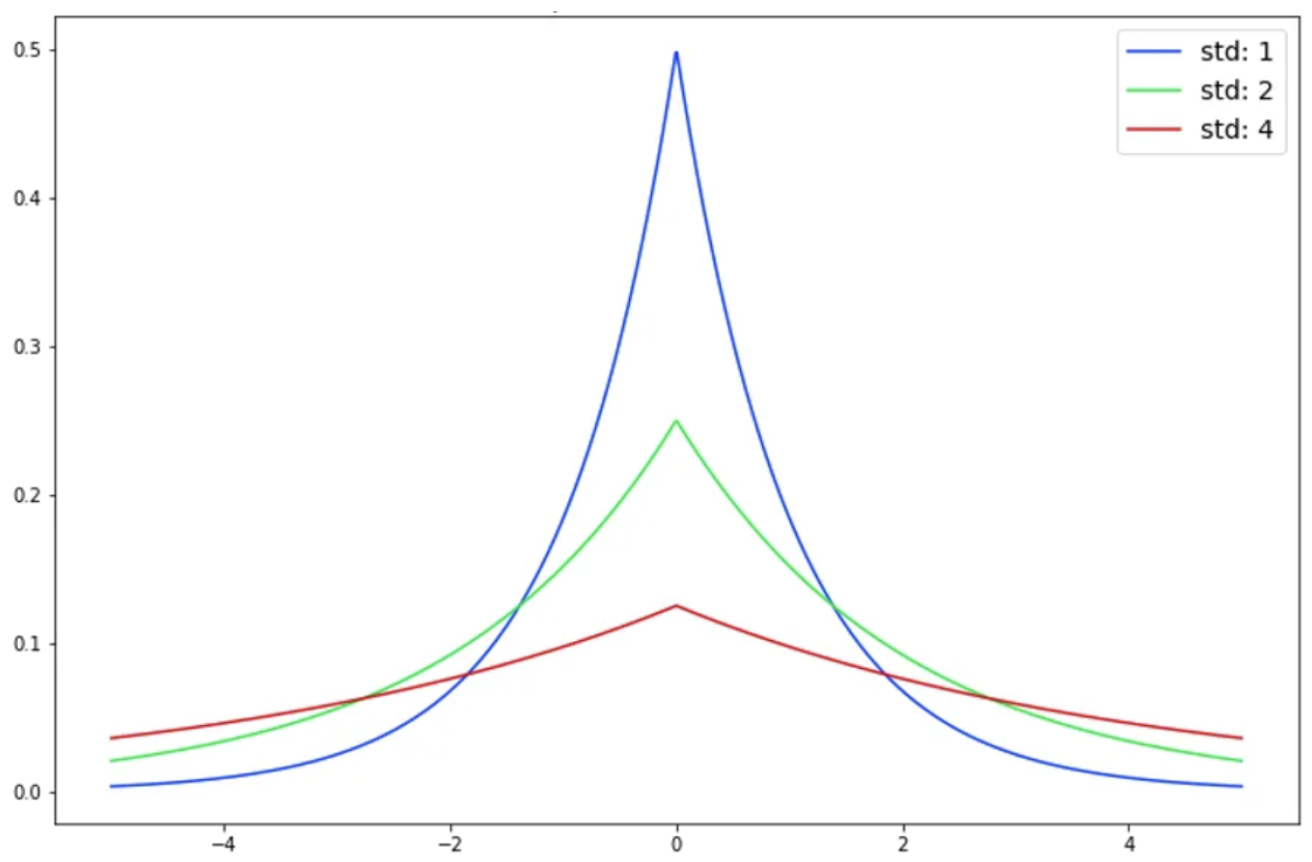

T напрямую влияет на дельты: при малом T модель концентрирует дельты около нуля и делает большинство из них малыми, что делает тренд менее гибким. При большем T дельты становятся больше, давая тренду больше гибкости. Концептуально это похоже на регуляризацию в функции потерь. Параметр changepoint_prior_scale определяет T.

В результате, **низкий changepoint_prior_scale = менее гибкий тренд, высокий = более гибкий тренд.**

In [ ]:
print('Default params:\n')

print(f'changepoint_prior_scale = {m.changepoint_prior_scale}\n')

Ожидается, что он будет установлен в пределах [0,001, 0,5] (см. [рекомендации](https://facebook.github.io/prophet/docs/diagnostics.html) от авторов), однако вы можете настроить его. Исходя из моего личного опыта, я рекомендую настроить его в пределах [0,001, 1].

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_10 = fp.Prophet(changepoint_prior_scale=0.5)

# 2. Обучить модель
m_10.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_10.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_10 = m_10.predict(future)


fig5 = m.plot(forecast_10)
a = add_changepoints_to_plot(fig5.gca(), m_10, forecast_10)

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_11 = fp.Prophet(changepoint_prior_scale=0.001)

# 2. Обучить модель
m_11.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_11.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_11 = m_11.predict(future)

fig6 = m.plot(forecast_11)
a = add_changepoints_to_plot(fig6.gca(), m_11, forecast_11)

## Праздники

В Prophet датафрейм с праздниками должен иметь следующие столбцы:

* **holiday**: Название праздника (строковый тип).
* **ds**: Дата праздника (тип datetime).

Опционально вы можете включить следующие столбцы:
* **lower_window**: Количество дней до праздника для включения (целое число). По умолчанию 0.
* **upper_window**: Количество дней после праздника для включения (целое число). По умолчанию 0.

In [ ]:
holidays_df = pd.read_csv('holidays_events.csv', parse_dates=['date'])
holidays_df = holidays_df[(holidays_df['locale'] == 'National')&(holidays_df['locale_name'] == 'Ecuador')] # we'll take into account only national Ecuador holidays
holidays_df = holidays_df[['date', 'description']]
holidays_df.columns = ['ds', 'holiday']
holidays_df

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_12 = fp.Prophet(holidays=holidays_df)

# 2. Обучить модель
m_12.fit(train_fp)

# 3. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_12.make_future_dataframe(periods=forecast_horizon)

# 4. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_12 = m_12.predict(future)


In [ ]:
fig = px.line(title="Продажи")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='прогноз', line=dict(color='red'))
fig.add_scatter(x=forecast_12['ds'], y=forecast_12['yhat'], mode='lines', name='forecast with holidays', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="продажи")
fig.show()

Обратите внимание, что Prophet имеет гиперпараметр для контроля гибкости подгонки эффектов праздников — **holidays_prior_scale**. Это также можно настроить в диапазоне [0.01, 10], как и seasonality_prior_scale.

## Регрессоры

В Prophet также могут быть включены регрессоры. Эти регрессоры могут быть любыми переменными, которые могут иметь связь с целевой переменной.

Чтобы добавить регрессор в Prophet, вы используете метод *add_regressor()*. Вам нужно указать имя регрессора и убедиться, что столбец с тем же именем включен в ваши обучающую и прогнозную части.

In [ ]:
train_fp

In [ ]:
train_fp_with_reg = regressors.join(train_fp.set_index('ds'), how='inner')[['oil','y']].reset_index()
train_fp_with_reg

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_13 = fp.Prophet()

# 2. Добавить регрессор
m_13.add_regressor('oil')


# 3. Обучить модель
m_13.fit(train_fp_with_reg)

# 4. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_13.make_future_dataframe(periods=forecast_horizon)
future['oil'] = regressors['oil'].values[:1684] # Future regressor values

# 5. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_13 = m_13.predict(future)


In [ ]:
fig = px.line(title="Продажи")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='прогноз', line=dict(color='red'))
fig.add_scatter(x=forecast_13['ds'], y=forecast_13['yhat'], mode='lines', name='forecast with regs', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="продажи")
fig.show()

## Final model

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_final = fp.Prophet(holidays=holidays_df, seasonality_mode='multiplicative')

# 2. Добавить регрессор и сезонность
m_final.add_regressor('oil')

# Добавляем скорректированную месячную сезонность
m_final.add_seasonality(name = 'monthly',
                       period = 31,
                       fourier_order = 25)


# 3. Обучить модель
m_final.fit(train_fp_with_reg)

# 4. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_final.make_future_dataframe(periods=forecast_horizon)
future['oil'] = regressors['oil'].values[:1684] # Future regressor values

# 5. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_final = m_final.predict(future)

In [ ]:
fig = px.line(title="Продажи")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='прогноз', line=dict(color='red'))
fig.add_scatter(x=forecast_final['ds'], y=forecast_final['yhat'], mode='lines', name='forecast final', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="продажи")
fig.show()

In [ ]:
forecast_final['unique_id'] = 'sales'

evaluation_prophet_final = evaluate(
    test.merge(forecast_final[['unique_id','ds','yhat']]),
    metrics=metrics,
    train_df=train
)
evaluation_prophet_final

In [ ]:
print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

print('Base Prophet:')
display(evaluation_prophet)

print('Adjusted Prophet:')
display(evaluation_prophet_final)

## Sum up по Prophet

- Обсудили модель прогнозирования Prophet — ML модель прогнозирования
- Обсудили гиперпараметры, связанные с трендом и сезонностью
- Обсудили, как добавлять праздники и регрессоры в модель Prophet
- Оценили прогнозы с помощью RMSE и MAPE (и получили хорошие прогнозы)

# Тюнинг модели

## Кросс-валидация

Стандартный метод оценки качества нескольких альтернативных моделей — это кросс-валидация. Исходные обучающие данные случайным образом разделяются на K частей (блоков), после чего модель обучается K раз, используя K−1 блоков, а оставшийся блок используется каждый раз для валидации качества прогноза.

При работе с временными рядами применяются несколько модификаций классической кросс-валидации. Наиболее распространенными являются **кросс-валидация с расширяющимся окном** и **кросс-валидация со скользящим окном**. Мы будем использовать метод расширяющегося окна (Simulated Historical Forecasts, SHF), потому что это имеет больше смысла: с каждой итерацией ваша метрика основана на все большем количестве данных.

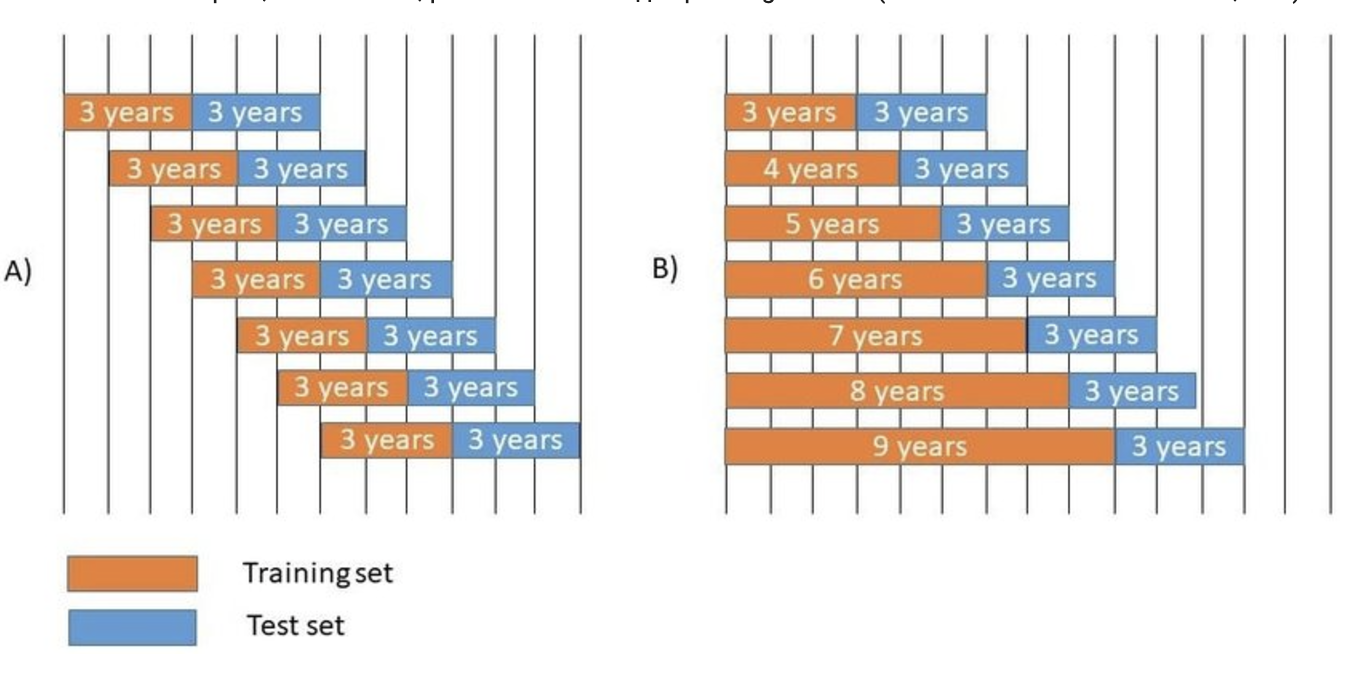

Функция Prophet *cross_validation()* принимает следующие параметры:

* *initial* ("начальное окно") – кол-во исторических наблюдений в первом фолде, которые формируют обучающие данные для подгонки соответствующей модели (по умолчанию это 3×H)

* *horizon* ("горизонт прогноза") – следующие H точек наблюдения после "начального окна", для которых строится прогноз

* *period* – – период, на который увеличивается значение "начального окна" перед следующим прогнозом (по умолчанию это H/2).

<img src="https://i.ibb.co/nsbjc6k/2023-04-04-16-04-49.png">
Каждый раз после подгонки модели к обучающим данным из k-го блока делаются прогнозы для горизонта прогноза того же блока, что позволяет оценить качество прогноза с помощью соответствующей метрики (например, MAPE, см. ниже). Значения этого показателя, усредненные по каждой дате прогноза по всем блокам, в конечном итоге дают оценку качества прогноза, которое можно ожидать от модели, построенной на основе всех исходных обучающих данных. Это, в свою очередь, позволяет сравнить несколько альтернативных моделей и выбрать оптимальную.

🐀 **Что мы делаем в кросс-валидации ниже, на основе параметров initial, period и horizon?**

In [ ]:
df_cv = cross_validation(m_final, initial='365.25 days', period='90 days', horizon = '180 days', parallel="processes")

Результат кросс-валидации — это таблица с обучающими данными, исключая начальный период, но теперь для каждого наблюдения был рассчитан прогноз.

In [ ]:
df_cv

Функция *performance_metrics* вычисляет основные типы ошибок. Параметр *rolling_window* контролирует долю наблюдений в фолде, на основе которой вычисляется ошибка. Мы используем все данные фолда для расчета ошибки.

In [ ]:
res = performance_metrics(df_cv, rolling_window = 1)
res

Давайте сравним результаты кросс-валидации и ранее рассчитанное качество.

In [ ]:
print('Adjusted Prophet:')
display(evaluation_prophet_final)

## Grid search

**Grid search** (поиск по сетке) — это метод, используемый в машинном обучении и статистическом моделировании для поиска лучших гиперпараметров для заданной модели. Он работает путем исчерпывающего поиска по вручную указанному подмножеству пространства гиперпараметров, называемому **сеткой**. В grid search модель обучается и оценивается для каждой возможной комбинации гиперпараметров в пространстве поиска.

Например, если у вас есть два гиперпараметра (например, $\alpha$ и $\beta$), вы можете определить сетку возможных значений для каждого. Grid search затем оценит модель на каждой возможной комбинации этих значений. Цель состоит в том, чтобы найти комбинацию, которая дает наилучшую производительность, обычно используя валидационное множество или кросс-валидацию для оценки точности модели.

Grid search вычислительно дорогостоящ, поскольку он оценивает каждую возможную комбинацию. Однако его просто реализовать, и он гарантирует нахождение лучших параметров в пределах указанной сетки. Более продвинутые методы, такие как случайный поиск, байесовская оптимизация и фреймворки, такие как Hyperopt и Optuna, являются более эффективными альтернативами, но grid search — широко используемая техника, особенно когда пространство гиперпараметров мало.

In [ ]:
param_grid = {
    'changepoint_prior_scale': [0.05,0.1,0.5],
    'seasonality_prior_scale': [0.001,0.1,10.0],
    'seasonality_mode':['multiplicative','additive'],
    'holidays_prior_scale':[1.0,5.0,10.0]
}

# Создать все комбинации параметров
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

len(all_params)

🐀 **Сколько моделей мы будем тестировать?**

In [ ]:
mapes = []

# Cross validation
for params in tqdm(all_params):
    m = fp.Prophet(**params, holidays=holidays_df)  # Fit model with given params
    m.add_regressor('oil', mode=params['seasonality_mode'])
    m.fit(train_fp_with_reg)
    df_cv = cross_validation(m, initial='365.25 days', period='180 days', horizon = '180 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    mapes.append(df_p['mape'].values[0])

In [ ]:
# Найти лучшие параметры
tuning_results = pd.DataFrame(all_params)
tuning_results['mape'] = mapes
tuning_results.sort_values(by='mape')

In [ ]:
best_params = all_params[tuning_results.sort_values(by='mape').index[0]]
best_params

## Лучшая модель

Давайте обучим лучшую модель.

In [ ]:
# 1. Создать объект класса Prophet (все параметры модели устанавливаются в конструкторе класса, используя значения по умолчанию)
m_tuned = fp.Prophet(holidays=holidays_df, **best_params)

# 2. Добавить регрессор
m_tuned.add_regressor('oil')

# 3. Обучить модель
m_tuned.fit(train_fp_with_reg)

# 4. Создать таблицу с датами, охватывающую как исторические данные, так и "горизонт прогноза"
future = m_tuned.make_future_dataframe(periods=forecast_horizon)
future['oil'] = regressors['oil'].values[:1684] # Future regressor values

# 5. Получить прогнозы для дат, сгенерированных на предыдущем шаге
forecast_tuned = m_tuned.predict(future)


In [ ]:
fig = px.line(title="Продажи")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='прогноз', line=dict(color='red'))
fig.add_scatter(x=forecast_tuned['ds'], y=forecast_tuned['yhat'], mode='lines', name='forecast tuned', line=dict(color='violet'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="продажи")
fig.show()

In [ ]:
forecast_tuned['unique_id'] = 'sales'

evaluation_prophet_tuned = evaluate(
    test.merge(forecast_tuned[['unique_id','ds','yhat']]),
    metrics=metrics,
    train_df=train
)
evaluation_prophet_tuned

In [ ]:
print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

print('Base Prophet:')
display(evaluation_prophet)

print('Adjusted Prophet:')
display(evaluation_prophet_final)

print('Tuned Prophet:')
display(evaluation_prophet_tuned)

## Sum up по настройке модели

- Обсудили кросс-валидацию и её модификации для задачи временных рядов
- Обсудили grid search для настройки гиперпараметров
- Настроили нашу модель Prophet и получили лучший прогноз Prophet

# Статистические модели

**Статистические модели прогнозирования** (иногда также называемые **эконометрическими**) — это важные инструменты в анализе временных рядов, позволяющие компаниям и исследователям прогнозировать будущие значения на основе исторических данных. Среди различных моделей MSTL (Multivariate Seasonal-Trend decomposition using Loess), Holt-Winters, Theta и Seasonal Naive являются популярными методами, которые предлагают различные преимущества в зависимости от структуры и характеристик данных.

Все эти модели можно найти в *statsforecast.*

## Seasonal naive

Давайте подумаем о сезонности. Мы уже обсуждали, что в целом для прогнозирования сезонностей могут использоваться более сложные подходы (например, ряды Фурье), но мы также можем сделать это таким образом:

$\hat{y}{T+h|T}=y{T+h−m(k+1)}$,

где m — это сезонный период, а k — целая часть от ( ℎ − 1 ) / 𝑚 (h−1)/m (то есть количество полных сезонов в периоде прогноза до времени T + h).

Это выглядит сложнее, чем есть на самом деле: например, для месячных данных прогноз для всех будущих значений февраля будет равен последнему наблюдаемому значению февраля. Для дневных данных с недельной сезонностью каждый прогнозируемый суббота будет равен последней наблюдаемой субботе.

Эта модель называется **Seasonal Naive**.

In [ ]:
models = [SeasonalNaive(season_length=7)]
sf = StatsForecast(models=models, freq='D', n_jobs=-1)

forecast = sf.forecast(df=train, h=forecast_horizon)
forecast

In [ ]:
fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['SeasonalNaive'], mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [ ]:
evaluation_seasonal_naive = evaluate(
    test.merge(forecast),
    metrics=metrics,
    train_df=train
)
evaluation_seasonal_naive

In [ ]:
print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

print('Base Prophet:')
display(evaluation_prophet)

print('Adjusted Prophet:')
display(evaluation_prophet_final)

print('Tuned Prophet:')
display(evaluation_prophet_tuned)


print('Seasonal Naive:')
display(evaluation_seasonal_naive)

## MSTL

** Модель прогнозирования MSTL в statsforecast тесно связана с декомпозицией MSTL и представляет собой сложный подход, разработанный для обработки данных временных рядов с несколькими сезонными моделями и тенденциями.

**Алгоритм**
* Разложите временной ряд с помощью MSTL-декомпозиции на три компонента: тренд, сезонность (множественные сезонности) и остаточные значения.
* Смоделируйте трендовый компонент с помощью предопределенной модели (например, AutoARIMA), чтобы отобразить долгосрочный тренд и закономерности в данных.
* Моделируйте сезонные компоненты, используя Seasonal Naive, в котором будущие сезонные значения основаны на прошлых сезонных наблюдениях (например, на последнем наблюдаемом значении за тот же день недели или месяц).
* Объедините прогнозы трендового и сезонного компонентов для получения окончательного прогноза.
* Используйте остатки (при необходимости) в качестве случайного шума или для дальнейшего уточнения модели.

[Подробнее](https://nixtlaverse.nixtla.io/statsforecast/docs/models/multipleseasonaltrend.html)

In [ ]:
models = [
    MSTL(
        season_length=[7, 31, 365], # определить сезонные периоды
        trend_forecaster=AutoARIMA()
        # (method='CSS-ML') # могут быть разные модели, но давайте пока используем AutoARIMA
        )
]

sf = StatsForecast(models=models, freq='D', n_jobs=-1)

forecast = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['MSTL'], mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [ ]:
evaluation_MSTL = evaluate(
    test.merge(forecast),
    metrics=metrics,
    train_df=train
)

print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

print('Base Prophet:')
display(evaluation_prophet)

print('Adjusted Prophet:')
display(evaluation_prophet_final)

print('Tuned Prophet:')
display(evaluation_prophet_tuned)

print('Seasonal Naive:')
display(evaluation_seasonal_naive)

print('MSTL:')
display(evaluation_MSTL)

## Theta

Модель **Theta** - это метод прогнозирования временных рядов, который сочетает классическую декомпозицию временных рядов с подходом коррекции тренда. Она особенно хорошо подходит для наборов данных с сильными трендами и сезонностью. Эта модель была представлена Assimakopoulos и Nikolopoulos в 2000 году и известна своей простотой и эффективностью в широком спектре приложений для прогнозирования.

AutoTheta - это автоматизированная версия модели Theta, предназначенная для упрощения процесса настройки параметров модели и улучшения процесса прогнозирования. AutoTheta автоматически выбирает наилучшие параметры модели (включая трендовую и сезонную составляющие) для заданного временного ряда на основе характеристик данных, оптимизируя прогноз без необходимости ручного вмешательства или детального понимания данных.

[Подробнее](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autotheta.html)

In [ ]:
models = [
    AutoTheta(season_length=7)
]

sf = StatsForecast(models=models, freq='D', n_jobs=-1)

forecast = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['AutoTheta'], mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [ ]:
evaluation_autoTheta = evaluate(
    test.merge(forecast),
    metrics=metrics,
    train_df=train
)

print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

print('Base Prophet:')
display(evaluation_prophet)

print('Adjusted Prophet:')
display(evaluation_prophet_final)

print('Tuned Prophet:')
display(evaluation_prophet_tuned)

print('Seasonal Naive:')
display(evaluation_seasonal_naive)

print('MSTL:')
display(evaluation_MSTL)

print('Auto Theta:')
display(evaluation_autoTheta)

## Holt-Winters

Модель **Holt-Winters** (Холта-Винтерса), также известная как модель тройного экспоненциального сглаживания, является популярным методом прогнозирования временных рядов, который расширяет возможности простого экспоненциального сглаживания для учета сезонности, тенденций и уровней в данных. Это особенно полезно, когда данные демонстрируют сезонность и тенденции.

[Подробнее](https://nixtlaverse.nixtla.io/statsforecast/docs/models/holtwinters.html)

In [ ]:
models = [
    HoltWinters(season_length=365)
]

sf = StatsForecast(models=models, freq='D', n_jobs=-1)

forecast = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Sales")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['HoltWinters'], mode='lines', name='прогноз', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="y")
fig.show()

In [ ]:
evaluation_HoltWinters = evaluate(
    test.merge(forecast),
    metrics=metrics,
    train_df=train
)

print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

print('Base Prophet:')
display(evaluation_prophet)

print('Adjusted Prophet:')
display(evaluation_prophet_final)

print('Tuned Prophet:')
display(evaluation_prophet_tuned)

print('Seasonal Naive:')
display(evaluation_seasonal_naive)

print('MSTL:')
display(evaluation_MSTL)

print('Auto Theta:')
display(evaluation_autoTheta)

print('Holt-Winters:')
display(evaluation_HoltWinters)

## Nixtla pipeline

In [ ]:
regressors = regressors[['oil', 'holiday']]

In [ ]:
train_with_reg = train.set_index('ds').join(regressors).reset_index()

In [ ]:
regressors_fcst = regressors.loc['2017-01-01':].reset_index()
regressors_fcst['unique_id'] = 'sales'
regressors_fcst

**!!!Примечание: Регрессоры влияют только на тренд и только если наш тренд — Auto-ARIMA!!!**

In [ ]:
models = [
    MSTL(
        season_length=[7, 31, 365], # определить сезонные периоды
        trend_forecaster=AutoARIMA()
        # (method='CSS-ML') # могут быть разные модели, но только AutoARIMA будет работать с регрессорами
        ),
    HoltWinters(season_length=365),
    AutoTheta(season_length=7),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(
    models=models,
    freq='D',
    fallback_model = HistoricAverage() # the model that will be used in case of any errors
)

forecast = sf.forecast(df=train_with_reg, h=forecast_horizon, X_df=regressors_fcst)

forecast

In [ ]:
fig = px.line(title="Продажи")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))

fig.add_scatter(x=forecast['ds'], y=forecast['MSTL'], mode='lines', name='forecast MSTL with reg')
fig.add_scatter(x=forecast['ds'], y=forecast['HoltWinters'], mode='lines', name='forecast HoltWinters')
fig.add_scatter(x=forecast['ds'], y=forecast['AutoTheta'], mode='lines', name='forecast AutoTheta')
fig.add_scatter(x=forecast['ds'], y=forecast['SeasonalNaive'], mode='lines', name='forecast SeasonalNaive')

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="продажи")
fig.show()

In [ ]:
evaluation_MSTL_with_reg = evaluate(
    test.merge(forecast[['unique_id','ds','MSTL']]),
    metrics=metrics,
    train_df=train
)

print('SARIMA:')
display(evaluation_sarima)

print('SARIMAX:')
display(evaluation_sarimax)

print('Base Prophet:')
display(evaluation_prophet)

print('Adjusted Prophet:')
display(evaluation_prophet_final)

print('Tuned Prophet:')
display(evaluation_prophet_tuned)

print('Seasonal Naive:')
display(evaluation_seasonal_naive)

print('MSTL:')
display(evaluation_MSTL)

print('MSTL with reg:')
display(evaluation_MSTL_with_reg)

print('Auto Theta:')
display(evaluation_autoTheta)

print('Holt-Winters:')
display(evaluation_HoltWinters)

## Cross validation

В *statsforecast.cross_validation()* метод позволяет автоматически выполнять кросс-валидацию.


In [ ]:
def evaluate_cross_validation(df, metric):
    models = df.drop(columns=['unique_id', 'ds', 'cutoff', 'y']).columns.tolist()
    evals = []
    # Вычислить потери для каждого unique_id и отсечки.
    for cutoff in df['cutoff'].unique():
        eval_ = evaluate(df[df['cutoff'] == cutoff], metrics=[metric], models=models)
        evals.append(eval_)
    evals = pd.concat(evals)
    evals = evals.groupby('unique_id').mean(numeric_only=True) # Averages the error metrics for all cutoffs for every combination of model and unique_id
    evals['best_model'] = evals.idxmin(axis=1)
    return evals

In [ ]:
crossvalidation_df = sf.cross_validation(
    df = train_with_reg,
    h = 180, # forecasting for 180 days
    step_size = 90, # do steps of 90 days
    n_windows = 10
  ).reset_index()

cutoffs = crossvalidation_df.cutoff.unique()


In [ ]:
evaluation_df = evaluate_cross_validation(crossvalidation_df, rmse)
evaluation_df

In [ ]:
evaluation_df = evaluate_cross_validation(crossvalidation_df, mape)
evaluation_df

🐀 **Какая модель лучшая?**

# SUM UP

- Поняли другой тип декомпозиции — мультипликативную
- Использовали модель SARIMAX из statsforecast
- Использовали модель прогнозирования Prophet с праздниками и регрессорами и узнали, как её гиперпараметры контролируют поведение модели, связанное с трендом и сезонностью
- Обсудили алгоритмы настройки модели: кросс-валидацию и grid search и настроили модель прогнозирования Prophet
- Обсудили несколько статистических (или эконометрических) моделей прогнозирования из statsforecast: MSTL, Theta, Seasonal Naive и Holt-Winters
- Использовали кросс-валидацию из statsforecast для выбора лучшей статистической модели прогнозирования

Please, **suggest you themes for lessons 11-12** and leave your feedback [here](https://docs.google.com/forms/d/e/1FAIpQLSfMHsQ40JZ0Svc2SvdY62cnaFBdEZGJQndd11RGbGgvqF-mRw/viewform?usp=sharing), let's make our lessons more effective :)